# FigureSI_ — Emitter-density performance sweep

*Makes up Figures S38–S42.*

How detection/fitting performance (Jaccard index, precision, recall) degrades as emitter
density rises, for three real dyes (ATTO 488/565/647N) and three colour-blind "synthetic"
counterparts sharing the same PSF size but a flat, dye-independent per-pixel QE (isolating
PSF-size effects from Bayer colour-discrimination effects) — at three photon budgets each.
Ground truth is fully known (this is simulated data), so recovered localisations are matched
against it via optimal Hungarian assignment within a `match_multiplier × σ_PSF` radius, and
scored the same way `notebooks/analyses/` scores real fits.

**`FAST_MODE` flag (below):** `True` (default) runs a small, fast illustrative version —
a handful of densities, few frames per condition, a small image — that demonstrates the same
method and trend in well under a minute. `FAST_MODE = False` runs the actual full sweep this
figure was published with (100 density steps × 3 photon levels × 6 dyes × 1000 frames at
512×512, two PFA thresholds) — expect this to take **hours**, not minutes, and to write a
large volume of intermediate TIFF/H5 output to `outputs/` (git-ignored) beside this notebook.

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tifffile
import xarray as xr
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

from pyS3M import IOFunctions, SpectralFunctions, MaskFunctions, PSFFunctions, PlottingBase
from pyS3M.simulation.multicolour import MultiC_Sim_Funcs
from pyS3M.AnalysisPipeline import AnalysisPipeline
# Bare import (not `from src.ImageAnalysisFunctions import ...`): AnalysisPipeline/SR_Functions
# add src/ to sys.path and bare-import ImageAnalysisFunctions internally -- importing via the
# `src.` package path would register a second, distinct FittingStrategy Enum class that isn't
# the one FittingConstants.PARAM_DIMENSIONS is keyed on.
from pyS3M.ImageAnalysisFunctions import FittingStrategy
from pyS3M.Constants import ResultColumns

IO = IOFunctions.IO_Functions()
S_F = SpectralFunctions.Spectral_Funcs()
M_F = MaskFunctions.Mask_Functions()
PSF = PSFFunctions.PSF_Functions()
MSF = MultiC_Sim_Funcs()
plotter = PlottingBase.PublicationPlotter()

REPO_ROOT = Path.cwd().resolve().parents[2]
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"
OUT_ROOT = Path("outputs") / "EmitterDensityTests"  # git-ignored (see .gitignore's bare `outputs/` rule)

In [2]:
FAST_MODE = True  # False -> the real, hours-long full sweep this figure was published with

if FAST_MODE:
    image_size      = 128
    n_frames        = 20
    n_density_steps = 8
    pfa_conditions  = [1e-3]
else:
    image_size      = 512
    n_frames        = 1000
    n_density_steps = 100
    pfa_conditions  = [1e-3, 1e-4]

density_min, density_max = 0.01, 1.0   # emitters / µm², both modes
density_space   = np.linspace(density_min, density_max, n_density_steps)
n_photon_levels = [1000, 4000, 10_000]
bg_per_pixel    = 10.0                  # background photoelectrons per pixel per frame

# Emitters are kept this far from every edge so no emitter's ROI/PSF is clipped by the image
# boundary -- scales with image_size so the fraction of the image this excludes stays similar
# between FAST_MODE and the full sweep.
EDGE_MARGIN_PX = max(4, image_size // 40)

pixel_size    = 69.0             # nm/pixel (Ximea)
pixel_size_um = pixel_size * 1e-3
NA            = 1.49

image_area_um2   = (image_size * pixel_size_um) ** 2
emitter_area_um2 = ((image_size - 2 * EDGE_MARGIN_PX) * pixel_size_um) ** 2

print(f"FAST_MODE={FAST_MODE}")
print(f"Image: {image_size}x{image_size} px  ({image_size * pixel_size_um:.2f} um x {image_size * pixel_size_um:.2f} um)")
print(f"Density range: {density_min}-{density_max} /um^2  ({n_density_steps} steps)")
print(f"n_frames per stack: {n_frames}  |  photon levels: {n_photon_levels}  |  pfa: {pfa_conditions}")
print(f"N emitters at min/max density: {int(round(density_min * emitter_area_um2))} - {int(round(density_max * emitter_area_um2))}")

FAST_MODE=True
Image: 128x128 px  (8.83 um x 8.83 um)
Density range: 0.01-1.0 /um^2  (8 steps)
n_frames per stack: 20  |  photon levels: [1000, 4000, 10000]  |  pfa: [0.001]
N emitters at min/max density: 1 - 69


## Camera calibration & spectral setup

In [3]:
gain      = IO.read_tiff(str(CALIBRATION_DIR / "gain.tif"))
offset    = IO.read_tiff(str(CALIBRATION_DIR / "offset.tif"))
variance  = IO.read_tiff(str(CALIBRATION_DIR / "variance.tif"))
readnoise_map = IO.read_tiff(str(CALIBRATION_DIR / "readnoise.tif"))
rqe       = IO.read_tiff(str(CALIBRATION_DIR / "rqe.tif"))
readnoise = float(np.median(readnoise_map))
print(f"gain={np.median(gain):.4f}  offset={np.median(offset):.2f}  "
      f"variance={np.median(variance):.4f}  readnoise={readnoise:.2f}")

R_base, G_base, B_base, wavelength = S_F.getpixelefficiency()
pixel_QYs   = np.vstack([B_base, G_base, R_base])  # B=0, G=1, R=2
pixel_order = ["B", "G", "R"]
filters     = []

dyes = ["ATTO 488", "ATTO 565", "ATTO 647N",
        "synthetic_ATTO488", "synthetic_ATTO565", "synthetic_ATTO647N"]

masks = M_F.get_masks(size_x=image_size, size_y=image_size)
masks_stacked = M_F.get_stacked_masks(0, 0, image_size, image_size)
print("Mask channels:", {ch: int(m.sum()) for ch, m in masks.items()})

gain=0.4144  offset=32.35  variance=0.9374  readnoise=2.34
Mask channels: {'B': 4096, 'G': 8192, 'R': 4096}


## Per-condition camera calibration: resampled from real sensor pixels

Each simulated condition draws its own random resample of gain/offset/variance/rqe/readnoise
from the real calibration files — the *same* flat pixel indices reused across all five maps,
so a real hot/noisy sensor pixel's full calibration profile travels together into the
simulation, rather than being resampled independently per map. Seeded deterministically per
`(dye, n_photon, density)` condition so the fitting stage below can reconstruct the identical
maps a given condition's images were simulated with, without saving them separately.

In [4]:
def condition_seed(dye, n_photon, d_idx):
    i_dye = dyes.index(dye)
    i_photon = n_photon_levels.index(n_photon)
    return (i_dye * len(n_photon_levels) + i_photon) * len(density_space) + d_idx


def resample_camera_calibration(seed):
    rng = np.random.default_rng(seed)
    flat_idx = rng.choice(gain.size, size=image_size * image_size, replace=False)

    def _resample(cal_map):
        return cal_map.ravel()[flat_idx].reshape(image_size, image_size).astype(np.float64)

    return {
        "gain": _resample(gain), "offset": _resample(offset),
        "variance": _resample(variance), "rqe": _resample(rqe),
        "readnoise": _resample(readnoise_map),
    }


def build_simulation_calibration(resampled):
    return {
        "gain": resampled["gain"], "offset": resampled["offset"],
        "variance": resampled["variance"], "rqe": resampled["rqe"],
        "pixel_QYs": pixel_QYs, "pixel_order": pixel_order, "masks": masks,
    }


_example_cal = build_simulation_calibration(resample_camera_calibration(condition_seed(dyes[0], n_photon_levels[0], 0)))
print(f"resample_camera_calibration OK: shape={_example_cal['gain'].shape}  "
      f"gain_med={np.median(_example_cal['gain']):.4f}")

resample_camera_calibration OK: shape=(128, 128)  gain_med=0.4144


## Per-dye spectral parameters

`synthetic_<DYE>` entries model a hypothetical camera with the *same* PSF size as `<DYE>`
(same average emission wavelength → same σ) but with every pixel sharing a flat QE curve
(`Spectra/Camera_QE/Prime95B.csv`) instead of Ximea's per-channel Bayer QE — i.e. no colour
discrimination at all — isolating pure PSF-size effects from spectral/colour ones.

In [5]:
p95b_raw    = np.loadtxt(REPO_ROOT / "Spectra" / "Camera_QE" / "Prime95B.csv", delimiter=",")
prime95b_qe = np.interp(wavelength, p95b_raw[:, 0], p95b_raw[:, 1] / 100.0)

SYNTHETIC_SOURCE_DYE = {
    "synthetic_ATTO488": "ATTO 488", "synthetic_ATTO565": "ATTO 565", "synthetic_ATTO647N": "ATTO 647N",
}

dye_params = {}
for dye in dyes:
    if dye in SYNTHETIC_SOURCE_DYE:
        source_dye = SYNTHETIC_SOURCE_DYE[dye]
        aew = dye_params[source_dye]["aew_nm"]
        # normalized=False (not True, as for the real dyes below): feeding an identical curve
        # into every channel row under normalized=True collapses to 1/3 for ANY curve by
        # symmetry, making Prime95B's actual QE irrelevant.
        _, abs_qe = S_F.get_pixel_fractions_dye_and_filters(
            [source_dye], filters, wavelength, prime95b_qe[np.newaxis, :], normalized=False
        )
        dpe_arr = np.full(3, float(np.ravel(abs_qe)[0]))
    else:
        aew, dpe_raw = S_F.get_pixel_fractions_dye_and_filters([dye], filters, wavelength, pixel_QYs)
        aew = float(aew)
        dpe_arr = np.array(dpe_raw).ravel()

    sigma_px = PSF.sigma_PSF(float(aew), NA) / pixel_size
    dye_params[dye] = {"dpe": dpe_arr, "sigma_px": sigma_px, "aew_nm": float(aew)}
    print(f"{dye:20s}  aew={float(aew):.0f} nm  sigma={sigma_px:.3f} px  dpe={np.round(dpe_arr, 3)}")

ATTO 488              aew=539 nm  sigma=1.180 px  dpe=[ 0.139  0.751  0.11 ]
ATTO 565              aew=612 nm  sigma=1.340 px  dpe=[ 0.03   0.387  0.584]
ATTO 647N             aew=685 nm  sigma=1.501 px  dpe=[ 0.065  0.214  0.721]
synthetic_ATTO488     aew=539 nm  sigma=1.180 px  dpe=[ 0.94  0.94  0.94]
synthetic_ATTO565     aew=612 nm  sigma=1.340 px  dpe=[ 0.928  0.928  0.928]
synthetic_ATTO647N    aew=685 nm  sigma=1.501 px  dpe=[ 0.851  0.851  0.851]


## Simulate: one TIFF stack + ground-truth CSV per (dye, photon level, density)

Frames are generated in batches to bound peak memory. Existing output is skipped (so a FULL
sweep interrupted partway through can resume where it left off without redoing finished work).

In [6]:
OUT_ROOT.mkdir(parents=True, exist_ok=True)
BATCH = 500

n_total_cond = len(dyes) * len(n_photon_levels) * len(density_space)
i_cond, t0_total = 0, time.time()

for dye in dyes:
    dye_str = dye.replace(" ", "_")
    dp = dye_params[dye]
    dpe, aew_nm = dp["dpe"], dp["aew_nm"]

    for n_photon in n_photon_levels:
        ph_dir = OUT_ROOT / dye_str / f"{n_photon}ph"
        ph_dir.mkdir(parents=True, exist_ok=True)

        for d_idx, density in enumerate(density_space):
            i_cond += 1
            N_emitters = max(1, int(round(density * emitter_area_um2)))
            stem = f"d{d_idx:02d}_density{density:.4f}"
            tif_path = ph_dir / f"{stem}_images.tif"
            gt_path = ph_dir / f"{stem}_gt.csv"

            if tif_path.exists() and gt_path.exists():
                continue

            cal = build_simulation_calibration(resample_camera_calibration(condition_seed(dye, n_photon, d_idx)))
            gt_rows = []

            with tifffile.TiffWriter(tif_path, bigtiff=True) as tif:
                for b_start in range(0, n_frames, BATCH):
                    b_end = min(n_frames, b_start + BATCH)
                    b_size = b_end - b_start

                    pos_min_nm = EDGE_MARGIN_PX * pixel_size
                    pos_max_nm = (image_size - EDGE_MARGIN_PX) * pixel_size
                    x_nm = np.random.uniform(pos_min_nm, pos_max_nm, (b_size, N_emitters))
                    y_nm = np.random.uniform(pos_min_nm, pos_max_nm, (b_size, N_emitters))
                    x0y0_batch = {dye: np.stack([x_nm, y_nm], axis=1)}

                    bayer_batch, _, _ = MSF.gen_camera_image_stack(
                        cal, wavelength, aew_nm, dpe,
                        {dye: np.full(b_size, float(n_photon))}, x0y0_batch,
                        smoothing_function=None, background_photons=bg_per_pixel,
                        background_colour=[1.0] * len(pixel_order), NA=NA, pixel_size=pixel_size,
                    )
                    bayer_batch = np.asarray(bayer_batch).reshape(b_size, image_size, image_size)

                    for frame_img in bayer_batch:
                        tif.write(frame_img.astype(np.uint16), contiguous=True)

                    for fi in range(b_size):
                        for em_id in range(N_emitters):
                            gt_rows.append({
                                "frame_idx": b_start + fi, "emitter_id": em_id,
                                "x_px": float(x_nm[fi, em_id] / pixel_size),
                                "y_px": float(y_nm[fi, em_id] / pixel_size),
                                "n_photons": n_photon,
                            })

            pd.DataFrame(gt_rows).to_csv(gt_path, index=False)

            if i_cond % max(1, n_total_cond // 10) == 0 or i_cond == n_total_cond:
                t_elapsed = (time.time() - t0_total) / 60
                print(f"[{i_cond:4d}/{n_total_cond}] {dye:20s}  {n_photon:6d}ph  d{d_idx:02d}  "
                      f"N={N_emitters:4d}  elapsed={t_elapsed:.1f}m")

print(f"Simulation done in {(time.time() - t0_total) / 60:.1f} min.")

[  14/144] ATTO 488                4000ph  d05  N=  49  elapsed=0.0m


[  28/144] ATTO 565                1000ph  d03  N=  30  elapsed=0.0m


[  42/144] ATTO 565               10000ph  d01  N=  10  elapsed=0.0m


[  56/144] ATTO 647N               1000ph  d07  N=  69  elapsed=0.1m


[  70/144] ATTO 647N              10000ph  d05  N=  49  elapsed=0.1m


[  84/144] synthetic_ATTO488       4000ph  d03  N=  30  elapsed=0.1m


[  98/144] synthetic_ATTO565       1000ph  d01  N=  10  elapsed=0.1m


[ 112/144] synthetic_ATTO565       4000ph  d07  N=  69  elapsed=0.1m


[ 126/144] synthetic_ATTO647N      1000ph  d05  N=  49  elapsed=0.1m


[ 140/144] synthetic_ATTO647N     10000ph  d03  N=  30  elapsed=0.1m
[ 144/144] synthetic_ATTO647N     10000ph  d07  N=  69  elapsed=0.1m
Simulation done in 0.1 min.


## Quick visual check: sample frames at low, mid, high density

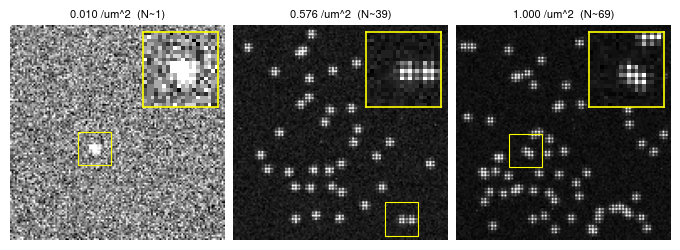

In [7]:
check_dye = "ATTO 647N"
check_n_photon = n_photon_levels[1]
check_frame = 0
check_d_idxs = [0, n_density_steps // 2, n_density_steps - 1]
INSET_HALF_PX = max(6, image_size // 12)

fig, axs = plotter.two_column_plot(ncols=3)

for ax, d_idx in zip(axs, check_d_idxs):
    density = density_space[d_idx]
    stem = f"d{d_idx:02d}_density{density:.4f}"
    ph_dir = OUT_ROOT / check_dye.replace(" ", "_") / f"{check_n_photon}ph"
    tif_path, gt_path = ph_dir / f"{stem}_images.tif", ph_dir / f"{stem}_gt.csv"

    with tifffile.TiffFile(tif_path) as tif:
        frame = tif.pages[check_frame].asarray()

    n_em = max(1, int(round(density * emitter_area_um2)))
    vmin, vmax = np.percentile(frame, [1, 99])
    ax.imshow(frame, cmap="gray", vmin=vmin, vmax=vmax, origin="upper")
    ax.set_title(f"{density:.3f} /um^2  (N~{n_em})", fontsize=8)
    ax.axis("off")

    gt = pd.read_csv(gt_path)
    gt_frame = gt[gt["frame_idx"] == check_frame]
    if len(gt_frame) > 0:
        ex, ey = gt_frame.iloc[0][["x_px", "y_px"]]
        x0, x1 = int(np.clip(ex - INSET_HALF_PX, 0, image_size)), int(np.clip(ex + INSET_HALF_PX, 0, image_size))
        y0, y1 = int(np.clip(ey - INSET_HALF_PX, 0, image_size)), int(np.clip(ey + INSET_HALF_PX, 0, image_size))
        crop = frame[y0:y1, x0:x1]

        axins = ax.inset_axes([0.62, 0.62, 0.35, 0.35])
        axins.imshow(crop, cmap="gray", vmin=vmin, vmax=vmax, origin="upper")
        axins.set_xticks([]); axins.set_yticks([])
        for spine in axins.spines.values():
            spine.set_edgecolor("yellow"); spine.set_linewidth(1.2)
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor="yellow", facecolor="none", lw=0.8))

plt.show()

## Spot detection + fitting

Detect and fit each simulated condition at each PFA threshold; `synthetic_*` dyes carry no
real per-channel colour signal (`dye_params[dye]['dpe']` is uniform across channels), so
they're fit with `FittingStrategy.NOCOLOUR` (intensity-only) instead of `STANDARD_DATA` —
whose output shape doesn't match `ResultColumns.get_all_columns()`, hence the separate
`result_params_nocolour` column list below (verified empirically against a real `NOCOLOUR`
fit's `fit_arr`/`err_arr` shapes).

In [8]:
pipe = AnalysisPipeline(camera="ximea", pixel_size=pixel_size_um)
pipe.load_calibration(CALIBRATION_DIR)
SR_F = pipe.sr
sf = pipe.make_smoothing_function(sigma=1.5)

result_params = ResultColumns.get_all_columns()
result_params_nocolour = [
    "xc", "yc", "s_x", "s_y", "bg", "A", "chi_sqr", "frame",
    "xc_err", "yc_err", "s_x_err", "s_y_err", "bg_err", "A_err",
]
ROI_size = 16


def pfa_tag(pfa):
    return f"pfa{pfa:.0e}".replace("e-0", "e-")


def condition_tag(pfa):
    return f"none_{pfa_tag(pfa)}_ft0p00"


n_total = len(dyes) * len(n_photon_levels) * len(density_space) * len(pfa_conditions)
i_cond, t0_loop = 0, time.time()

for dye in dyes:
    dye_str = dye.replace(" ", "_")
    aew_um = dye_params[dye]["aew_nm"] / 1000.0
    is_synthetic = dye in SYNTHETIC_SOURCE_DYE

    for n_photon in n_photon_levels:
        ph_dir = OUT_ROOT / dye_str / f"{n_photon}ph"

        for d_idx, density in enumerate(density_space):
            stem = f"d{d_idx:02d}_density{density:.4f}"
            tif_path = ph_dir / f"{stem}_images.tif"
            h5_paths = {pfa: ph_dir / f"{stem}_{condition_tag(pfa)}.h5" for pfa in pfa_conditions}
            i_cond += len(h5_paths)

            if all(p.exists() for p in h5_paths.values()):
                continue

            resampled_cal = resample_camera_calibration(condition_seed(dye, n_photon, d_idx))
            gain_c = resampled_cal["gain"].astype(np.float32)
            offset_c = resampled_cal["offset"].astype(np.float32)
            var_c = resampled_cal["variance"].astype(np.float32)
            rqe_c = resampled_cal["rqe"].astype(np.float32)
            rn_c = resampled_cal["readnoise"].astype(np.float32)

            raw = IO.read_tiff(str(tif_path), dtype="float32")
            if raw.ndim == 2:
                raw = raw[np.newaxis]

            for pfa in pfa_conditions:
                h5_path = h5_paths[pfa]
                if h5_path.exists():
                    continue

                detected, quality = SR_F.spot_detection.detect_puncta_in_stack_parallel(
                    raw, pfa=pfa, variance=var_c, wavelength=aew_um,
                    pixel_size=pixel_size_um, NA=NA, sigma=1.5,
                    fraction_true=0.0, return_quality=True,
                )

                (puncta, smoothed, mask_rois, weights, coords, planes, qm) = SR_F._process_detected_puncta_batch(
                    raw, detected, image_size, image_size, ROI_size, sf, rn_c, masks_stacked,
                    gain_map=gain_c, offset_map=offset_c, rqe=rqe_c,
                    frame_offset=0, is_multi_frame=True, quality_metrics=quality,
                )

                if len(puncta) == 0:
                    fit_df = pd.DataFrame(columns=result_params_nocolour if is_synthetic else result_params)
                elif is_synthetic:
                    fit_arr, err_arr = SR_F.image_analysis.fit_puncta_parallel_method(
                        puncta, smoothed, weights, coords, planes, FittingStrategy.NOCOLOUR,
                    )
                    fit_df = SR_F._postprocess_fit_results(
                        fit_arr, err_arr, result_params_nocolour, planes, image_size, image_size, quality_metrics=qm,
                    )
                else:
                    fit_arr, err_arr = SR_F.image_analysis.fit_puncta_parallel_method(
                        puncta, smoothed, weights, coords, planes, FittingStrategy.STANDARD_DATA, masks=mask_rois,
                    )
                    fit_df = SR_F._postprocess_fit_results(
                        fit_arr, err_arr, result_params, planes, image_size, image_size, quality_metrics=qm,
                    )

                IO.write_h5_database(fit_df, str(h5_path), normalise_photons=True, verbose=False)

            if i_cond % max(1, n_total // 10) < len(pfa_conditions):
                t_elapsed = (time.time() - t0_loop) / 60
                print(f"[{i_cond:5d}/{n_total}]  {dye:20s}  {n_photon:6d}ph  d{d_idx:02d}  elapsed={t_elapsed:.1f}m")

print(f"Detection + fitting done in {(time.time() - t0_loop) / 60:.1f} min")

INFO:pyS3M.AnalysisPipeline:AnalysisPipeline initialised (camera=ximea, pixel_size=0.0690 µm)


INFO:pyS3M.AnalysisPipeline:Calibration loaded from /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/Camera_Calibrations/Ximea_Camera


Detecting puncta:   0%|          | 0/20 [00:00<?, ?it/s]

Detecting puncta:   0%|          | 0/20 [00:00<?, ?it/s]

Detecting puncta:   0%|          | 0/20 [00:00<?, ?it/s]

...

Detecting puncta:   0%|          | 0/20 [00:00<?, ?it/s]

Detecting puncta:   0%|          | 0/20 [00:00<?, ?it/s]

Detecting puncta:   0%|          | 0/20 [00:00<?, ?it/s]

Detecting puncta:   0%|          | 0/20 [00:00<?, ?it/s]

Detection + fitting done in 1.2 min


## Quality filter & matching metrics

`apply_quality_filter` mirrors `SR_Functions`'s own physical fit checks (finite/in-image
centre, positive sigma), plus two checks specific to this sweep: a minimum photon count (the
full-sweep data showed a broad low-photon outlier population — junk fits indistinguishable
from good ones by `chi_sqr` alone), and rejecting `STANDARD_DATA` fits whose colour split
never moved away from its `A_B=A_G=A_R=1/3` initial guess (`synthetic_*`/`NOCOLOUR` fits have
no colour split to check).

`compute_metrics` matches recovered localisations against ground truth via optimal 1:1
Hungarian assignment per frame within a `match_multiplier x sigma_px` radius, then reports
Jaccard/PPV/recall/FP-rate/missed-rate. **Axis convention (verified empirically against the
current `gen_camera_image_stack`, not assumed):** ground truth's `x_px`/`y_px` correspond
directly to fitted `xc`/`yc` -- no axis swap needed (the older dev notebook this was ported
from documented a swap for an earlier version of the simulator; that convention has since
changed, confirmed by overlaying a bright, isolated emitter's fit against its raw-frame peak
pixel before trusting the sweep below).

In [9]:
MIN_PHOTONS_QC = 500.0
COLOUR_GUESS_TOL = 1e-3


def apply_quality_filter(locs_df, image_size, min_photons=MIN_PHOTONS_QC, colour_guess_tol=COLOUR_GUESS_TOL):
    if len(locs_df) == 0:
        return locs_df
    df = locs_df.dropna(subset=["xc", "yc", "s_x", "s_y"]).copy()
    mask = (
        (df["xc"] > 0) & (df["xc"] < image_size) & (df["yc"] > 0) & (df["yc"] < image_size)
        & (df["s_x"] > 0) & (df["s_y"] > 0)
    )
    if "photons" in df.columns:
        mask &= df["photons"] >= min_photons
    elif "A" in df.columns:
        mask &= df["A"] >= min_photons
    if all(c in df.columns for c in ("A_B", "A_G", "A_R")):
        stuck_at_guess = (
            (np.abs(df["A_B"] - 1 / 3) < colour_guess_tol)
            & (np.abs(df["A_G"] - 1 / 3) < colour_guess_tol)
            & (np.abs(df["A_R"] - 1 / 3) < colour_guess_tol)
        )
        mask &= ~stuck_at_guess
    return df[mask].reset_index(drop=True)


match_mode, match_multiplier = "sigma", 2.0


def compute_metrics(gt_df, locs_df, match_mode, match_multiplier, sigma_px):
    use_dynamic_radius = match_mode == "error"
    static_radius = None if use_dynamic_radius else match_multiplier * sigma_px

    gt_dict = {f: g[["x_px", "y_px"]].values for f, g in gt_df.groupby("frame_idx")}
    loc_cols = ["xc", "yc", "xc_err", "yc_err"] if use_dynamic_radius else ["xc", "yc"]
    loc_dict = {f: g[loc_cols].values for f, g in locs_df.groupby("frame")} if len(locs_df) else {}

    all_tp = all_fp = all_fn = 0
    for frame in set(gt_dict) | set(loc_dict):
        gt_xy = gt_dict.get(frame, np.empty((0, 2)))
        loc_v = loc_dict.get(frame, np.empty((0, len(loc_cols))))
        loc_xy = loc_v[:, :2]
        n_gt, n_loc = len(gt_xy), len(loc_xy)

        if n_gt == 0 and n_loc == 0:
            continue
        if n_gt == 0:
            all_fp += n_loc; continue
        if n_loc == 0:
            all_fn += n_gt; continue

        radius = match_multiplier * np.abs(loc_v[:, 2:4]).mean() if use_dynamic_radius else static_radius
        dist_mat = cdist(loc_xy, gt_xy)
        cost = dist_mat.copy()
        cost[cost > radius] = 1e9
        row_ind, col_ind = linear_sum_assignment(cost)
        valid = dist_mat[row_ind, col_ind] <= radius
        tp = int(valid.sum())
        all_tp += tp; all_fp += n_loc - tp; all_fn += n_gt - tp

    tp, fp, fn = all_tp, all_fp, all_fn
    denom_jac = tp + fp + fn
    return dict(
        tp=tp, fp=fp, fn=fn, n_gt=int(gt_df["frame_idx"].count()), n_det=len(locs_df),
        jaccard=tp / denom_jac if denom_jac > 0 else np.nan,
        ppv=tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        recall=tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        fp_rate=fp / (tp + fp) if (tp + fp) > 0 else np.nan,
        missed=fn / (tp + fn) if (tp + fn) > 0 else np.nan,
    )

### Sanity check: fit vs ground-truth overlay (mid density, mid photon level)

Before trusting the full metrics sweep below, visually and numerically check one
representative condition end-to-end — exactly the kind of check that would catch an
axis-convention bug like the one `compute_metrics`'s docstring above describes.

ATTO 488  4000ph  density=0.5757/um^2  pfa=1e-03
780 ground-truth rows, 566 localisations pass quality filter
jaccard=0.666  ppv=0.951  recall=0.690


/tmp/ipykernel_2344516/3345222548.py:44: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


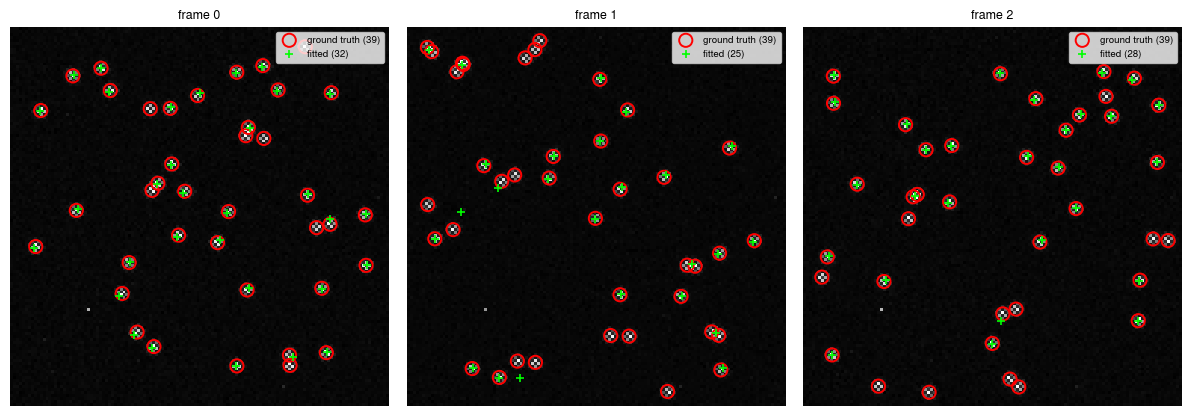

In [10]:
DIAG_DYE = dyes[0]
DIAG_N_PHOTON = n_photon_levels[1]
DIAG_D_IDX = len(density_space) // 2
DIAG_PFA = pfa_conditions[0]
DIAG_N_FRAMES_SHOW = min(3, n_frames)

dye_str = DIAG_DYE.replace(" ", "_")
sigma_px = dye_params[DIAG_DYE]["sigma_px"]
ph_dir = OUT_ROOT / dye_str / f"{DIAG_N_PHOTON}ph"
density = density_space[DIAG_D_IDX]
stem = f"d{DIAG_D_IDX:02d}_density{density:.4f}"

tif_path = ph_dir / f"{stem}_images.tif"
gt_path = ph_dir / f"{stem}_gt.csv"
h5_path = ph_dir / f"{stem}_{condition_tag(DIAG_PFA)}.h5"

gt_df = pd.read_csv(gt_path)
locs_df = apply_quality_filter(IO.read_h5_database(str(h5_path)), image_size)
m = compute_metrics(gt_df, locs_df, match_mode, match_multiplier, sigma_px)
print(f"{DIAG_DYE}  {DIAG_N_PHOTON}ph  density={density:.4f}/um^2  pfa={DIAG_PFA:.0e}")
print(f"{len(gt_df)} ground-truth rows, {len(locs_df)} localisations pass quality filter")
print(f"jaccard={m['jaccard']:.3f}  ppv={m['ppv']:.3f}  recall={m['recall']:.3f}")

with tifffile.TiffFile(tif_path) as tif:
    show_frames = list(range(DIAG_N_FRAMES_SHOW))
    frames_raw = [tif.pages[f].asarray() for f in show_frames]

fig, axs = plt.subplots(1, len(show_frames), figsize=(4.0 * len(show_frames), 4.0))
if len(show_frames) == 1:
    axs = [axs]
radius = match_multiplier * sigma_px
for ax, f in zip(axs, show_frames):
    vmin, vmax = np.percentile(frames_raw[f], [0.1, 99.9])
    ax.imshow(frames_raw[f], cmap="gray", vmin=vmin, vmax=vmax, origin="upper", interpolation="nearest")
    gt_frame = gt_df[gt_df["frame_idx"] == f]
    loc_frame = locs_df[locs_df["frame"] == f]
    ax.scatter(gt_frame["x_px"], gt_frame["y_px"], s=90, facecolors="none", edgecolors="red",
               linewidths=1.4, label=f"ground truth ({len(gt_frame)})")
    ax.scatter(loc_frame["xc"], loc_frame["yc"], s=40, marker="+", color="lime",
               linewidths=1.2, label=f"fitted ({len(loc_frame)})")
    ax.set_title(f"frame {f}", fontsize=9)
    ax.legend(loc="upper right", fontsize=7)
    ax.axis("off")
fig.tight_layout()
plt.show()

## Metrics sweep

Runs `compute_metrics` over every simulated `(dye, n_photon, density, pfa)` condition,
collecting results into both a tidy `metrics_df` and an `xarray.DataArray` (`Metrics_XR`,
saved to `outputs/EmitterDensityTests/emitter_density_metrics.nc`) for the figure below.

In [11]:
metric_names = ["jaccard", "ppv", "recall", "fp_rate", "missed", "tp", "fp", "fn", "n_gt", "n_det"]

Metrics_XR = xr.DataArray(
    data=np.full([len(dyes), len(n_photon_levels), len(density_space), len(pfa_conditions), len(metric_names)], np.nan),
    coords={"dye": dyes, "n_photon": n_photon_levels, "density": density_space,
            "pfa": pfa_conditions, "metric": metric_names},
    dims=["dye", "n_photon", "density", "pfa", "metric"],
)

rows = []
for i_dye, dye in enumerate(dyes):
    dye_str = dye.replace(" ", "_")
    sigma_px = dye_params[dye]["sigma_px"]

    for i_photon, n_photon in enumerate(n_photon_levels):
        ph_dir = OUT_ROOT / dye_str / f"{n_photon}ph"

        for d_idx, density in enumerate(density_space):
            stem = f"d{d_idx:02d}_density{density:.4f}"
            gt_df = pd.read_csv(ph_dir / f"{stem}_gt.csv")

            for i_pfa, pfa in enumerate(pfa_conditions):
                h5_path = ph_dir / f"{stem}_{condition_tag(pfa)}.h5"
                if not h5_path.exists():
                    continue
                locs_df = apply_quality_filter(IO.read_h5_database(str(h5_path)), image_size)
                m = compute_metrics(gt_df, locs_df, match_mode, match_multiplier, sigma_px)
                rows.append(dict(dye=dye, n_photon=n_photon, density=density, d_idx=d_idx, pfa=pfa, **m))
                Metrics_XR.values[i_dye, i_photon, d_idx, i_pfa, :] = [m[name] for name in metric_names]

metrics_df = pd.DataFrame(rows)
print(f"Metrics ready: {len(metrics_df)} rows")
metrics_nc_path = OUT_ROOT / "emitter_density_metrics.nc"
Metrics_XR.to_netcdf(metrics_nc_path)
print(f"Saved xarray metrics -> {metrics_nc_path}")

Metrics ready: 144 rows
Saved xarray metrics -> outputs/EmitterDensityTests/emitter_density_metrics.nc


## Figure: Jaccard / PPV / Recall vs density

One row per real dye; columns are Jaccard index, PPV (precision), and recall. Each real
dye's synthetic (colour-blind) counterpart is overlaid in black for comparison. Line style
distinguishes photon level; `pfa_conditions[0]` (the lowest-index PFA threshold) is used.

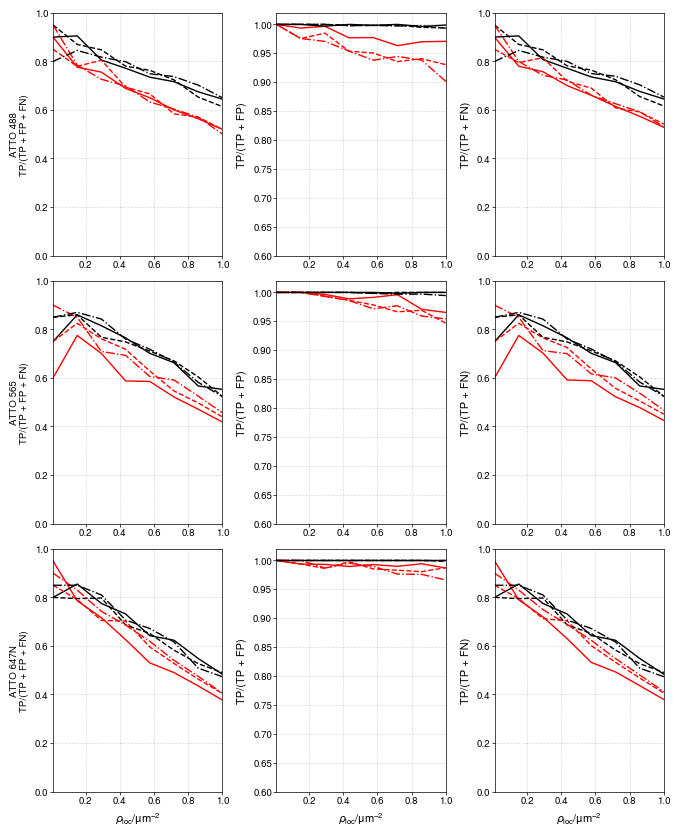

In [12]:
fig, axs = plotter.two_column_plot(ncols=3, nrows=3)

photon_ls = ["-", "--", "-."]
metric_idx = {"jaccard": 0, "ppv": 1, "recall": 2}
metric_labels = ["TP/(TP + FP + FN)", "TP/(TP + FP)", "TP/(TP + FN)"]
i_pfa_show = 0

for row in range(3):
    real_dye, synth_dye = dyes[row], dyes[row + 3]
    for col, metric in enumerate(["jaccard", "ppv", "recall"]):
        ax = axs[row, col]
        for photon_i, n_photon in enumerate(n_photon_levels):
            real_vals = Metrics_XR.sel(dye=real_dye, n_photon=n_photon, pfa=pfa_conditions[i_pfa_show], metric=metric)
            synth_vals = Metrics_XR.sel(dye=synth_dye, n_photon=n_photon, pfa=pfa_conditions[i_pfa_show], metric=metric)
            plotter.line_plot(ax, density_space, real_vals, linestyle=photon_ls[photon_i], color="red", ylabel=metric_labels[col])
            plotter.line_plot(ax, density_space, synth_vals, linestyle=photon_ls[photon_i], color="black", ylabel=metric_labels[col])
        ax.set_ylim([0.6, 1.02] if metric == "ppv" else [0, 1])
        ax.set_xlim([density_min, density_max])
        ax.set_xlabel(r"$\rho_\mathrm{loc}$/$\mathrm{\mu}$m$^{-2}$" if row == 2 else "")
        if col == 0:
            ax.set_ylabel(f"{real_dye}\n{metric_labels[col]}", fontsize=7)

plt.show()

## RGB channel-fraction histograms vs emitter density

Rows are the three real dyes; columns are four increasing emitter densities. Each panel
overlays unfilled channel-fraction histograms for all three photon levels (linestyle) —
dashed vertical lines mark each channel's true (noiseless) fraction. `synthetic_*` dyes carry
no real colour signal (fit `NOCOLOUR`), so this panel is real-dye only.

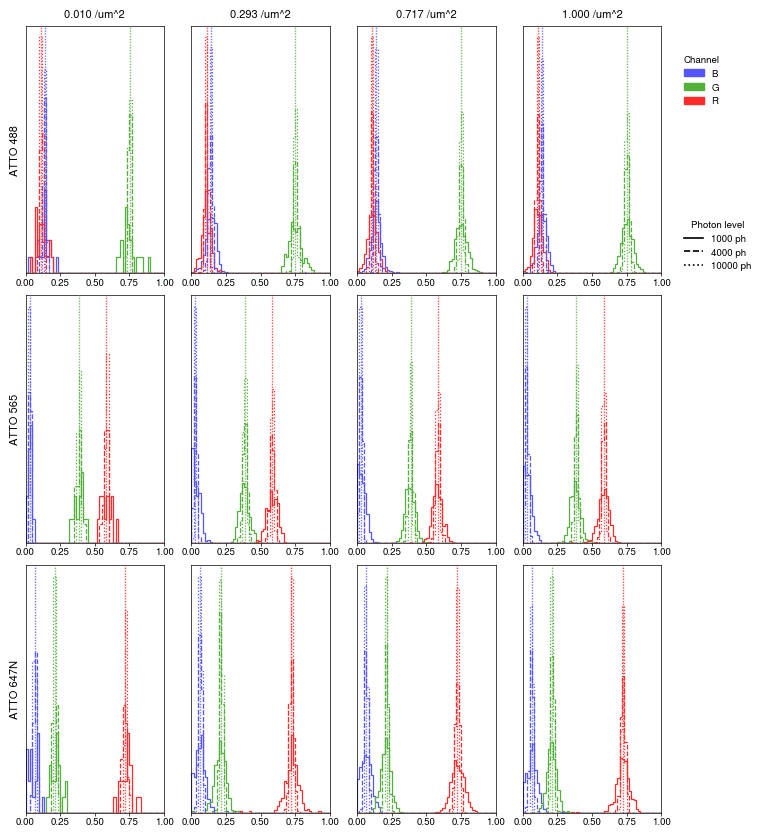

In [13]:
hist_dyes = dyes[:3]
hist_pfa = pfa_conditions[0]

n_hist_cols = min(4, n_density_steps)
hist_col_idx = np.round(np.linspace(0, n_density_steps - 1, n_hist_cols)).astype(int)
hist_densities = density_space[hist_col_idx]

col_names = ["A_B", "A_G", "A_R"]
col_labels = ["B", "G", "R"]
channel_colours = ["#5555ff", "#53b03b", "#ff2a2a"]
photon_linestyles = ["-", "--", ":"]
hist_bins, col_xlim = 60, (0.0, 1.0)

fig, axs = plotter.two_column_plot(nrows=len(hist_dyes), ncols=n_hist_cols)

for row, dye in enumerate(hist_dyes):
    dye_str = dye.replace(" ", "_")
    true_colour_dye = dye_params[dye]["dpe"] / np.sum(dye_params[dye]["dpe"])

    for col, (d_idx, density) in enumerate(zip(hist_col_idx, hist_densities)):
        ax = axs[row, col] if n_hist_cols > 1 else axs[row]
        stem = f"d{d_idx:02d}_density{density:.4f}"

        for ls, n_photon in zip(photon_linestyles, n_photon_levels):
            h5_path = OUT_ROOT / dye_str / f"{n_photon}ph" / f"{stem}_{condition_tag(hist_pfa)}.h5"
            if not h5_path.exists():
                continue
            locs = apply_quality_filter(IO.read_h5_database(str(h5_path)), image_size)
            if len(locs) < 5:
                continue
            for cname, cc in zip(col_names, channel_colours):
                vals = locs[cname].to_numpy()
                vals = vals[np.isfinite(vals)]
                if len(vals) < 5:
                    continue
                ax.hist(vals, bins=hist_bins, range=col_xlim, density=True, histtype="step",
                        color=cc, linestyle=ls, linewidth=0.9)

        for cc, tv in zip(channel_colours, true_colour_dye):
            ax.axvline(tv, color=cc, linewidth=1.0, linestyle=(0, (1, 1)), alpha=0.8, zorder=5)

        ax.set_xlim(col_xlim)
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f"{density:.3f} /um^2", fontsize=8)
        if col == 0:
            ax.set_ylabel(dye, fontsize=8)

channel_patches = [mpatches.Patch(facecolor=c, edgecolor=c, label=l) for c, l in zip(channel_colours, col_labels)]
photon_lines = [plt.Line2D([0], [0], color="k", linestyle=ls, lw=1.2, label=f"{n_photon} ph")
                for ls, n_photon in zip(photon_linestyles, n_photon_levels)]
fig.legend(handles=channel_patches, loc="upper left", bbox_to_anchor=(1.0, 0.95), fontsize=7, frameon=False, title="Channel")
fig.legend(handles=photon_lines, loc="upper left", bbox_to_anchor=(1.0, 0.75), fontsize=7, frameon=False, title="Photon level")
plt.show()

## Next steps

Set `FAST_MODE = False` above and re-run to reproduce the actual published sweep (100
density steps x 3 photon levels x 6 dyes x 1000 frames, two PFA thresholds) — expect hours,
not minutes, and a large `outputs/EmitterDensityTests/` directory of intermediate TIFF/H5/CSV
files (git-ignored) alongside this notebook.